# Proyecto 2

In [56]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import os
from pathlib import Path
import json
import torchvision.transforms as transforms_lib
from PIL import Image

# Configuración do dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: cuda


## Funciones del notebook de clase :)

Variance scheduler linear para difusió

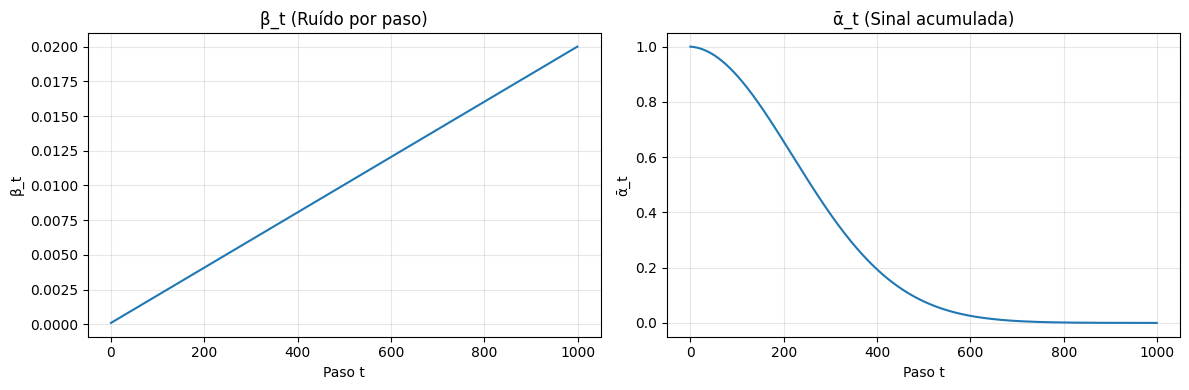

In [57]:
def linear_beta_schedule(timesteps, beta_start=0.0001, beta_end=0.02):
    """
    Crea un variance schedule lineal.
    
    Args:
        timesteps: número de pasos de difusión (T)
        beta_start: β_1
        beta_end: β_T
    
    Returns:
        beta_t: variance en cada paso
        alpha_t: 1 - β_t
        alpha_bar_t: produto acumulado de alpha_t
    """
    beta_t = torch.linspace(beta_start, beta_end, timesteps)
    alpha_t = 1.0 - beta_t
    alpha_bar_t = torch.cumprod(alpha_t, dim=0)
    
    return beta_t, alpha_t, alpha_bar_t

# Hiperparámetros
T = 1000  # Número de pasos de difusión
beta_t, alpha_t, alpha_bar_t = linear_beta_schedule(T)

# Visualización do schedule
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(beta_t.numpy())
ax1.set_title('β_t (Ruído por paso)')
ax1.set_xlabel('Paso t')
ax1.set_ylabel('β_t')
ax1.grid(True, alpha=0.3)

ax2.plot(alpha_bar_t.numpy())
ax2.set_title('ᾱ_t (Sinal acumulada)')
ax2.set_xlabel('Paso t')
ax2.set_ylabel('ᾱ_t')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Unet para predecir el ruido

In [ ]:
class TimeEmbedding(nn.Module):
    """Embedding sinusoidal para o tempo t."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat([torch.sin(embeddings), torch.cos(embeddings)], dim=-1)
        return embeddings


class ResBlock(nn.Module):
    """Bloque residual con inxección de tempo."""
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        # Primeira metade do bloque
        self.gn1 = nn.GroupNorm(8, in_channels)  # Normaliza a entrada
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        
        # Proxección do time embedding ao número de canles
        self.time_embedding_projector = nn.Linear(time_emb_dim, out_channels)
        
        # Segunda metade do bloque
        self.gn2 = nn.GroupNorm(8, out_channels)  # Normaliza despois da primeira conv
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        
        # Conexión residual
        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.residual_conv = nn.Identity()
    
    def forward(self, x, t_emb):
        # Primeira parte: GN → SiLU → Conv
        h = self.gn1(x)
        h = F.silu(h)
        h = self.conv1(h)
        
        # Inxección do embedding temporal
        projected_t_emb = self.time_embedding_projector(t_emb)
        h = h + projected_t_emb[:, :, None, None]
        
        # Segunda parte: GN → SiLU → Conv
        h = self.gn2(h)
        h = F.silu(h)
        h = self.conv2(h)
        
        # Conexión residual
        return h + self.residual_conv(x)


class SimpleUNet(nn.Module):
    """U-Net simplificada para imaxes en color (64x64)."""
    def __init__(self, in_channels=3, out_channels=3, time_emb_dim=128, base_channels=64):
        super().__init__()
        
        # Time embedding
        self.time_mlp = nn.Sequential(
            TimeEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        
        # Encoder (downsampling)
        self.conv_in = nn.Conv2d(in_channels, base_channels, 3, padding=1)
        self.down1 = ResBlock(base_channels, base_channels, time_emb_dim)
        self.down2 = ResBlock(base_channels, base_channels * 2, time_emb_dim)
        self.down3 = ResBlock(base_channels * 2, base_channels * 2, time_emb_dim)
        
        # Bottleneck
        self.bottleneck = ResBlock(base_channels * 2, base_channels * 2, time_emb_dim)
        
        # Decoder (upsampling)
        self.up1 = ResBlock(base_channels * 4, base_channels * 2, time_emb_dim)
        self.up2 = ResBlock(base_channels * 3, base_channels, time_emb_dim)
        self.up3 = ResBlock(base_channels, base_channels, time_emb_dim)
        
        # Output
        self.conv_out = nn.Conv2d(base_channels, out_channels, 1)
        
        # Pooling e upsampling
        self.pool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
    
    def forward(self, x, t):
        # Time embedding
        t_emb = self.time_mlp(t)
        
        # Encoder
        x1 = self.conv_in(x)
        x1 = self.down1(x1, t_emb)  # 64x64
        
        x2 = self.pool(x1)
        x2 = self.down2(x2, t_emb)  # 32x32
        
        x3 = self.pool(x2)
        x3 = self.down3(x3, t_emb)  # 16x16
        
        # Bottleneck
        x3 = self.bottleneck(x3, t_emb)
        
        # Decoder con skip connections
        x = self.upsample(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.up1(x, t_emb)  # 32x32
        
        x = self.upsample(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up2(x, t_emb)  # 64x64
        
        x = self.up3(x, t_emb)
        
        # Output
        return self.conv_out(x)


Difusión hacia delante y hacia atrás

In [59]:
def forward_diffusion(x0, t, alpha_bar_t):
    """
    Proceso de forward diffusion: engade ruído a x0.
    
    x_t = √(ᾱ_t) * x0 + √(1 - ᾱ_t) * ε
    
    Args:
        x0: imaxe orixinal [batch, channels, height, width]
        t: pasos de tempo [batch]
        alpha_bar_t: valores de ᾱ_t
    
    Returns:
        x_t: imaxe con ruído
        epsilon: ruído engadido
    """
    
    # Extraer ᾱ_t para cada t no batch
    alpha_bar = alpha_bar_t[t].view(-1, 1, 1, 1)
    
    # Xerar ruído gaussiano
    epsilon = torch.normal(mean=torch.zeros_like(x0), std=torch.ones_like(x0))
    
    # Aplicar forward diffusion
    x_t = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * epsilon
    
    return x_t, epsilon


def sample_timesteps(batch_size, timesteps):
    """Mostrear pasos de tempo aleatorios."""
    return torch.randint(0, timesteps, (batch_size,))

# Carga do dataset

In [60]:
from pathlib import Path
import zipfile
import requests
import warnings

def download_if_missing(url, output_path, verify_ssl=True):
    output_path = Path(output_path)
    if output_path.exists() and output_path.stat().st_size > 0:
        print(f"Xa descargado: {output_path}")
        return output_path

    print(f"Descargando {url} -> {output_path}")
    try:
        with requests.get(url, stream=True, timeout=60, verify=verify_ssl) as r:
            r.raise_for_status()
            with open(output_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
        return output_path
    except requests.exceptions.SSLError as e:
        warnings.warn(f"SSL verification failed: {e}. Retrying without verification.")
        with requests.get(url, stream=True, timeout=60, verify=False) as r:
            r.raise_for_status()
            with open(output_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
        return output_path

def unzip_if_needed(zip_path, target_dir):
    zip_path = Path(zip_path)
    target_dir = Path(target_dir)

    if target_dir.exists():
        print(f"Xa descomprimido: {target_dir}")
        return

    print(f"Descomprimindo: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(".")
    print(f"Listo: {target_dir}")

VAL_URL = "https://images.cocodataset.org/zips/val2017.zip"
ANN_URL = "https://images.cocodataset.org/annotations/annotations_trainval2017.zip"

val_zip = download_if_missing(VAL_URL, "val2017.zip")
ann_zip = download_if_missing(ANN_URL, "annotations_trainval2017.zip")

unzip_if_needed(val_zip, "val2017")
unzip_if_needed(ann_zip, "annotations")

print("Dataset COCO listo para usar.")

Xa descargado: val2017.zip
Xa descargado: annotations_trainval2017.zip
Xa descomprimido: val2017
Xa descomprimido: annotations
Dataset COCO listo para usar.


In [61]:
image_files = list(Path("val2017").glob("*.jpg"))
print(f"Imágenes encontradas: {len(image_files)}")

Imágenes encontradas: 5000


Mostrando: val2017/000000022479.jpg


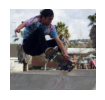

Mostrando: val2017/000000221281.jpg


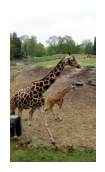

Mostrando: val2017/000000523033.jpg


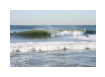

In [62]:
for i, img_path in enumerate(image_files[:3]):
    imagen = random.choice(image_files)
    print(f"Mostrando: {imagen}")
    img = plt.imread(imagen)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    

Guardamos los datos json de las anotaciones

In [63]:
ann_file = 'annotations/instances_val2017.json'
with open(ann_file, 'r') as f:
    data = json.load(f)

Supercategorías

In [64]:
supercats = set([cat['supercategory'] for cat in data['categories']])
print(supercats)

{'outdoor', 'electronic', 'kitchen', 'furniture', 'sports', 'indoor', 'food', 'person', 'animal', 'appliance', 'accessory', 'vehicle'}


In [65]:
for supercat in supercats:
    cat_ids = [cat['id'] for cat in data['categories'] if cat['supercategory'] == supercat]
    img_ids = set([ann['image_id'] for ann in data['annotations'] if ann['category_id'] in cat_ids])
    print(f"{supercat}: {len(img_ids)} imaxes")

outdoor: 560 imaxes
electronic: 597 imaxes
kitchen: 909 imaxes
furniture: 1257 imaxes
sports: 938 imaxes
indoor: 652 imaxes
food: 708 imaxes
person: 2693 imaxes
animal: 1016 imaxes
appliance: 320 imaxes
accessory: 726 imaxes
vehicle: 1160 imaxes


Selecciono la supercategoría "person"

In [66]:
supercategoria = "animal"

dataset_images = set()
for cat in data['categories']:
    if cat['supercategory'] == supercategoria:
        cat_id = cat['id']
        img_ids = set([ann['image_id'] for ann in data['annotations'] if ann['category_id'] == cat_id])
        dataset_images.update(img_ids)

ANN = Path('annotations') / 'instances_val2017.json'
SOURCE    = Path('val2017')
IMG_TAMAÑO = (64, 64)
OUTPUT = Path('dataset_animales')

nombres = [f"{img_id:012d}.jpg" for img_id in dataset_images]

missing = 0
processed = 0
for fname in nombres:
    src = SOURCE / fname
    dst = OUTPUT / fname
    if not src.exists():
        print(f"Advertencia: arquivo de orixe non existe: {src}")
        missing += 1
        continue
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        img = Image.open(src).convert('RGB').resize(IMG_TAMAÑO, Image.BICUBIC)
        img.save(dst, quality=95)
        processed += 1
    except Exception as e:
        print(f"Erro procesando {src}: {e}")

print(f'Procesados: {processed}; faltantes: {missing}')


Procesados: 1016; faltantes: 0


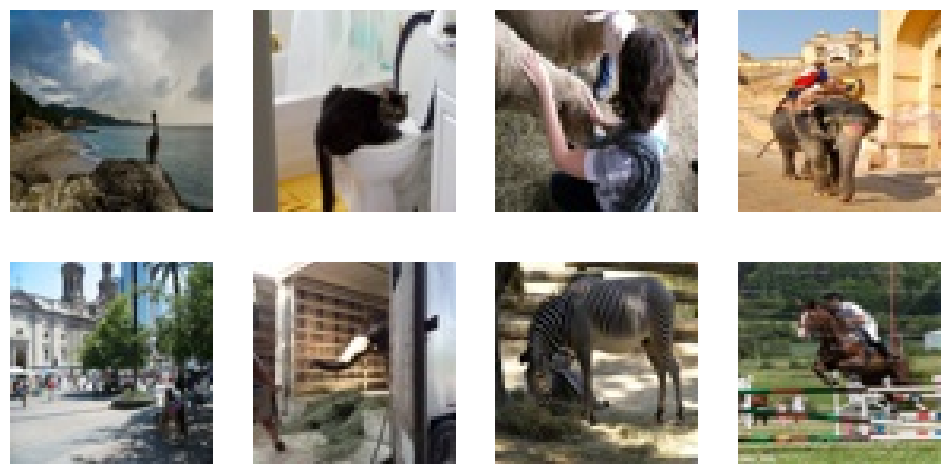

In [67]:
archivos = [OUTPUT / n for n in nombres[:8] if (OUTPUT / n).exists()]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.flat:
    ax.axis('off')
for ax, p in zip(axes.flat, archivos):
    ax.imshow(np.array(Image.open(p)))
    ax.axis('off')
plt.show()

Dataset cargado: 1016 imaxes de adestramento


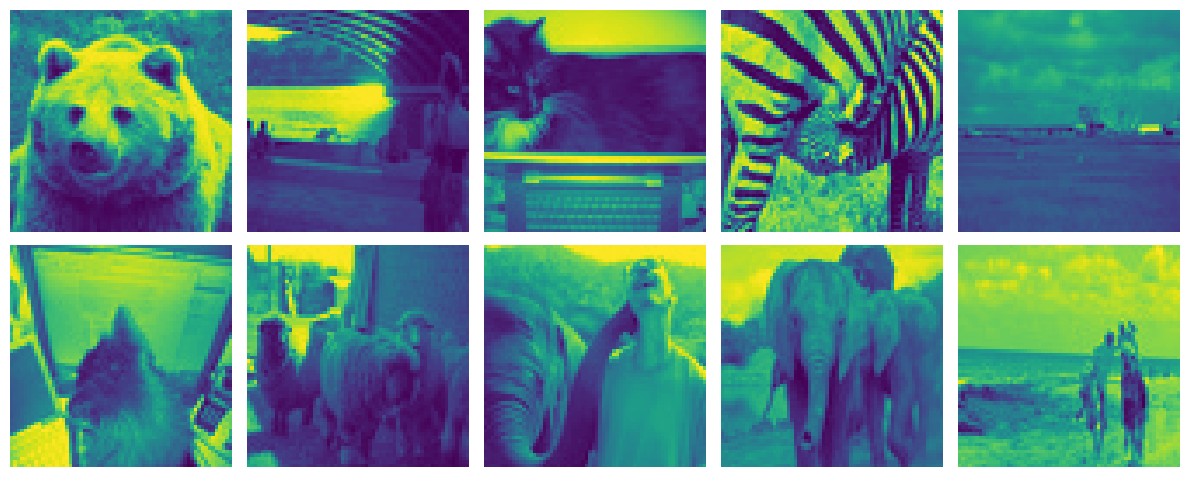

In [ ]:
from torch.utils.data import Dataset

# Transformacións
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalizar a [-1, 1] para 3 canais
])

# Cargar 
class ImageFolder64Dataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = Path(root)
        self.transform = transform
        self.image_paths = sorted(
            list(self.root.glob("*.jpg"))
        )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img

# Cargar dataset de imágenes 64x64
train_dataset = ImageFolder64Dataset("dataset_animales", transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)

print(f'Dataset cargado: {len(train_dataset)} imaxes de adestramento')

# Visualizar algunhas imaxes
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = train_dataset[i]
    # Desnormalizar de [-1,1] a [0,1] para mostrar
    img_vis = img.clone()
    img_vis = (img_vis * 0.5) + 0.5
    img_vis = img_vis.permute(1, 2, 0).numpy()
    ax.imshow(img_vis)
    ax.axis('off')
plt.tight_layout()
plt.show()

Bucle de entrenamiento

In [69]:
# Inicializar modelo
model = SimpleUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

# Mover schedules ao dispositivo
beta_t = beta_t.to(device)
alpha_t = alpha_t.to(device)
alpha_bar_t = alpha_bar_t.to(device)

# Hiperparámetros de adestramento
num_epochs = 10

print(f'Iniciando adestramento por {num_epochs} épocas...\n')

# Historial de perdas
losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
    pbar = tqdm(train_loader, desc=f'Época {epoch+1}/{num_epochs}')
    for batch_idx, x0 in enumerate(pbar):
        x0 = x0.to(device)
        batch_size = x0.shape[0]
        
        # Mostrear pasos de tempo aleatorios
        t = sample_timesteps(batch_size, T).to(device)
        
        # Forward diffusion (engadir ruído)
        x_t, epsilon = forward_diffusion(x0, t, alpha_bar_t)
        
        # Predecir o ruído
        epsilon_pred = model(x_t, t)
        
        # Calcular perda (MSE entre ruído real e predicido)
        loss = F.mse_loss(epsilon_pred, epsilon)
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        losses.append(loss.item())
        
        # Actualizar barra de progreso
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = epoch_loss / len(train_loader)
    print(f'Época {epoch+1}/{num_epochs} - Perda media: {avg_loss:.4f}')

print('\nAdestramento completado!')

Iniciando adestramento por 10 épocas...



Época 1/10: 100%|██████████| 8/8 [00:50<00:00,  6.29s/it, loss=0.2441]


Época 1/10 - Perda media: 0.7187


Época 2/10: 100%|██████████| 8/8 [00:45<00:00,  5.65s/it, loss=0.1566]


Época 2/10 - Perda media: 0.1988


...

Época 8/10 - Perda media: 0.0867


Época 9/10: 100%|██████████| 8/8 [00:45<00:00,  5.65s/it, loss=0.0804]


Época 9/10 - Perda media: 0.0912


Época 10/10: 100%|██████████| 8/8 [00:45<00:00,  5.65s/it, loss=0.0813]

Época 10/10 - Perda media: 0.0818

Adestramento completado!


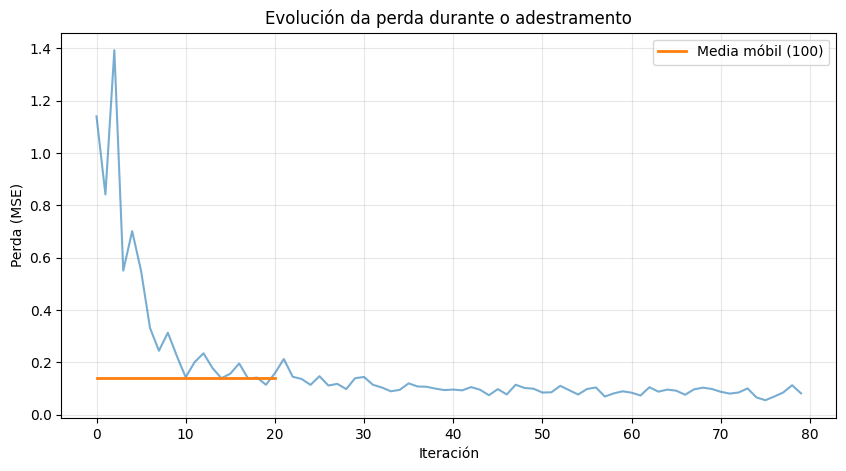

In [70]:
# Visualizar curva de perda
plt.figure(figsize=(10, 5))
plt.plot(losses, alpha=0.6)
plt.plot(np.convolve(losses, np.ones(100)/100, mode='valid'), linewidth=2, label='Media móbil (100)')
plt.xlabel('Iteración')
plt.ylabel('Perda (MSE)')
plt.title('Evolución da perda durante o adestramento')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Difusión al revés

In [ ]:
@torch.no_grad()
def sample_images(model, n_samples=16, image_size=64):
    """
    Xera imaxes utilizando reverse diffusion.
    
    Args:
        model: modelo adestrado
        n_samples: número de imaxes a xerar
        image_size: tamaño das imaxes
    
    Returns:
        imaxes xeradas
    """
    model.eval()
    
    # Comezar con ruído puro en 3 canles (RGB)
    x_t = torch.randn(n_samples, 3, image_size, image_size, device=device)
    
    # Reverse diffusion
    for t in tqdm(reversed(range(T)), desc='Xerando imaxes', total=T):
        t_batch = torch.full((n_samples,), t, dtype=torch.long).to(device)

        # Predecir o ruído
        epsilon_pred = model(x_t, t_batch)

        # Calcular coeficientes
        alpha = alpha_t[t]
        alpha_bar = alpha_bar_t[t]
        beta = beta_t[t]

        # Calcular x_{t-1}
        if t > 0:
            z = torch.randn_like(x_t)
            sigma_t = torch.sqrt(beta)
        else:
            z = torch.zeros_like(x_t)
            sigma_t = 0

        x_t = (1 / torch.sqrt(alpha)) * (
            x_t - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * epsilon_pred
        ) + sigma_t * z
    
    return x_t


# Xerar mostras
print('Xerando imaxes novas...')
generated_images = sample_images(model, n_samples=16, image_size=64)

# Desnormalizar imaxes de [-1, 1] a [0, 1]
generated_images = (generated_images + 1) / 2
generated_images = torch.clamp(generated_images, 0, 1)

# Visualizar imaxes xeradas (color)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    img = generated_images[i].cpu().permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Imaxes xerados polo DDPM', fontsize=16)
plt.tight_layout()
plt.show()

Xerando imaxes novas...


Xerando imaxes:   3%|▎         | 30/1000 [02:07<1:08:48,  4.26s/it]


KeyboardInterrupt: 

Visualización del proceso de difusión


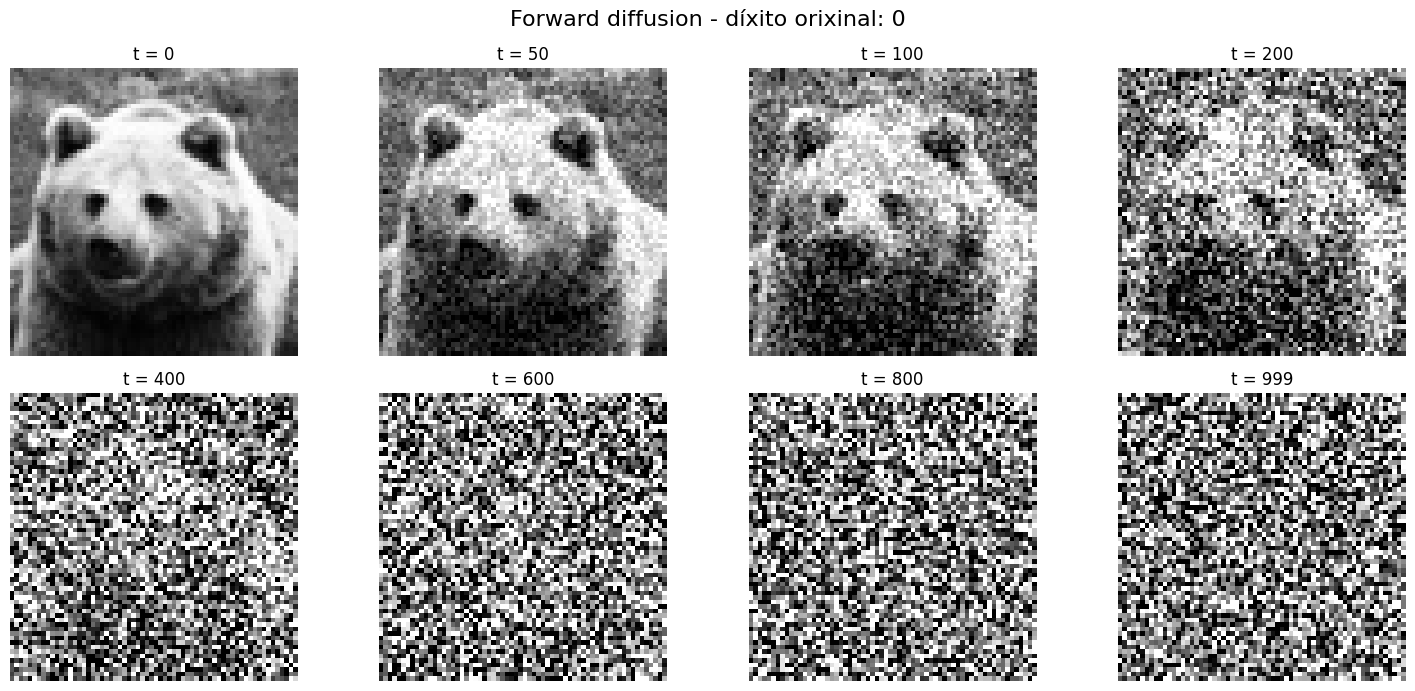

In [ ]:
# Seleccionar unha imaxe
img = train_dataset[0]
img = img.unsqueeze(0).to(device)

# Visualizar forward diffusion en diferentes pasos
timesteps_to_show = [0, 50, 100, 200, 400, 600, 800, 999]

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for idx, t in enumerate(timesteps_to_show):
    ax = axes[idx // 4, idx % 4]
    
    if t == 0:
        noisy_img = img
    else:
        t_tensor = torch.tensor([t]).to(device)
        noisy_img, _ = forward_diffusion(img, t_tensor, alpha_bar_t)
    
    # Desnormalizar
    noisy_img = (noisy_img + 1) / 2
    noisy_img = torch.clamp(noisy_img, 0, 1)
    
    # Mostrar en color
    img_disp = noisy_img.squeeze().permute(1, 2, 0).cpu().numpy()
    ax.imshow(img_disp)
    ax.set_title(f't = {t}')
    ax.axis('off')

plt.suptitle(f'Forward diffusion - díxito orixinal: {label}', fontsize=16)
plt.tight_layout()
plt.show()

Visualización del proceso de generación


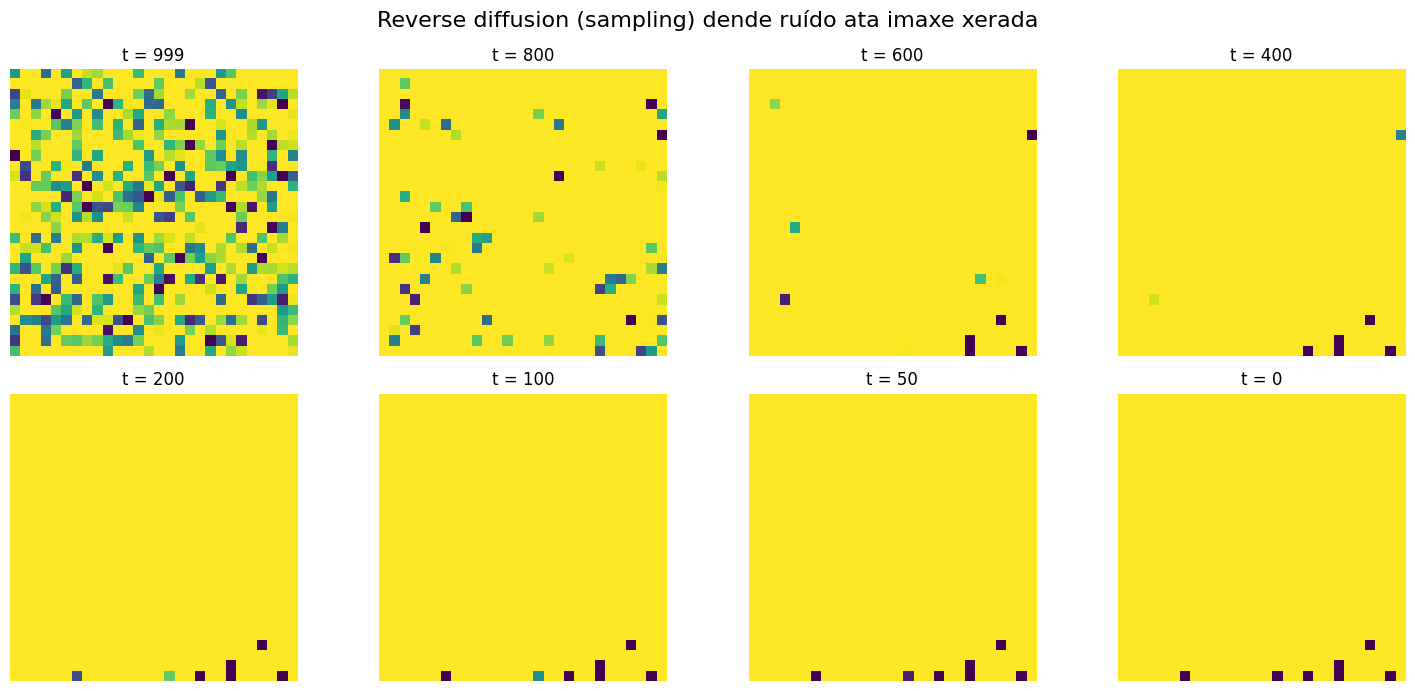

In [ ]:
# Visualizar reverse diffusion (comezando dende ruído)
model.eval()
reverse_timesteps_to_show = [999, 800, 600, 400, 200, 100, 50, 0]
capture_set = set(reverse_timesteps_to_show)
reverse_samples = {}

with torch.no_grad():
    # CAMBIO 1: Tamaño 64x64 y distribución normal estándar (0, 1)
    x_t = torch.randn((1, 3, 64, 64), device=device) 
    
    for t_step in reversed(range(T)):
        if t_step in capture_set:
            reverse_samples[t_step] = x_t.detach().cpu()
        
        t_batch = torch.full((1,), t_step, dtype=torch.long, device=device)
        epsilon_pred = model(x_t, t_batch)
        
        alpha = alpha_t[t_step]
        alpha_bar = alpha_bar_t[t_step]
        beta = beta_t[t_step]
        
        if t_step > 0:
            z = torch.randn_like(x_t)
            sigma_t = torch.sqrt(beta)
        else:
            z = torch.zeros_like(x_t)
            sigma_t = 0.0
            
        x_t = (1 / torch.sqrt(alpha)) * (
            x_t - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * epsilon_pred
        ) + sigma_t * z

# Plot corregido
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for idx, t_step in enumerate(reverse_timesteps_to_show):
    ax = axes[idx // 4, idx % 4]
    img = reverse_samples[t_step]
    # Desnormalizar de [-1, 1] a [0, 1]
    img = (img + 1) / 2
    img = torch.clamp(img, 0, 1)
    img_disp = img.squeeze().permute(1, 2, 0).numpy()
    ax.imshow(img_disp)
    ax.set_title(f't = {t_step}')
    ax.axis('off')
plt.show()

Comparación

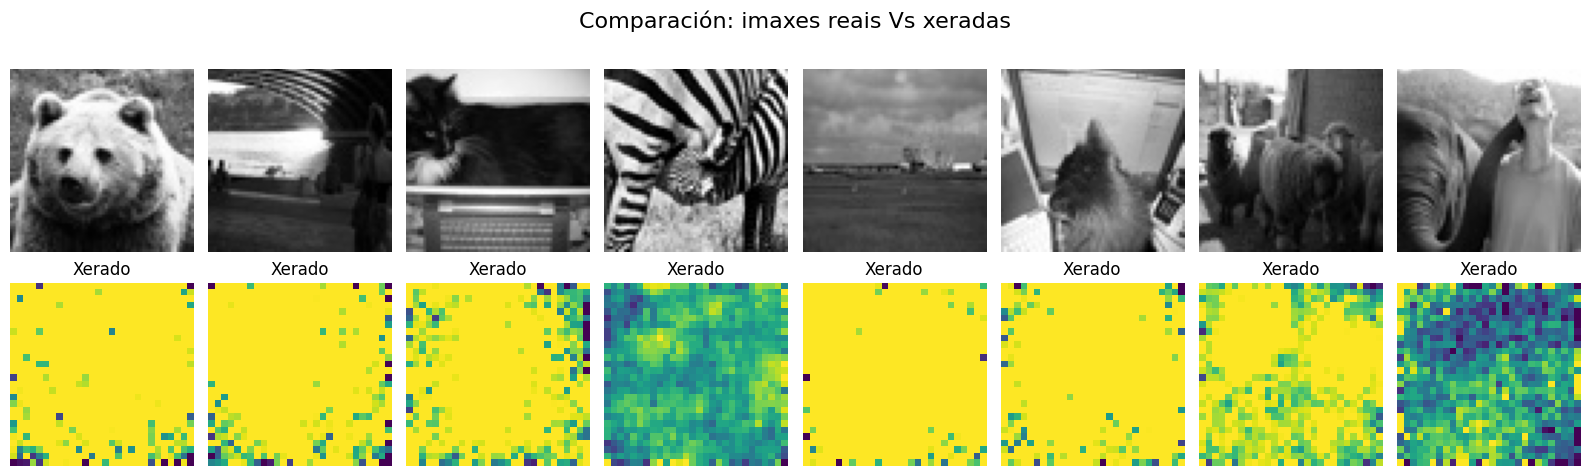

In [ ]:
# Mostrar lado a lado imaxes reais e xeradas
fig, axes = plt.subplots(2, 8, figsize=(16, 5))

# Imaxes reais
for i in range(8):
    img = train_dataset[i]
    img_disp = (img + 1) / 2
    img_disp = img_disp.permute(1, 2, 0).numpy()
    axes[0, i].imshow(img_disp)
    axes[0, i].axis('off')

# Imaxes xeradas
for i in range(8):
    gen = generated_images[i].cpu()
    gen_disp = gen.permute(1, 2, 0).numpy()
    axes[1, i].imshow(gen_disp)
    axes[1, i].set_title('Xerado')
    axes[1, i].axis('off')

plt.suptitle('Comparación: imaxes reais Vs xeradas', fontsize=16)
plt.tight_layout()
plt.show()

Evaliación cuantitativa


In [80]:
from scipy.linalg import sqrtm
from torchvision.models import inception_v3, Inception_V3_Weights

# A rede InceptionV3 espera imaxes de 3x299x299, así que convertímolas
@torch.no_grad()
def preprocess_for_inception(images):
    if images.shape[1] == 1:
        images = images.repeat(1, 3, 1, 1)
    return F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)


@torch.no_grad()
def get_inception_features(images, feature_extractor, batch_size=32):
    features = []

    for i in range(0, images.shape[0], batch_size):
        batch = images[i:i + batch_size].to(device)
        batch = preprocess_for_inception(batch)
        feats = feature_extractor(batch)
        if isinstance(feats, tuple):
            feats = feats[0]
        features.append(feats.cpu())

    return torch.cat(features, dim=0).numpy()


def calculate_fid(real_features, fake_features, eps=1e-6):
    mu_real = np.mean(real_features, axis=0)
    mu_fake = np.mean(fake_features, axis=0)

    sigma_real = np.cov(real_features, rowvar=False) + eps * np.eye(real_features.shape[1])
    sigma_fake = np.cov(fake_features, rowvar=False) + eps * np.eye(fake_features.shape[1])

    covmean = sqrtm(sigma_real @ sigma_fake)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    diff = mu_real - mu_fake
    return float(diff @ diff + np.trace(sigma_real + sigma_fake - 2 * covmean))

n_fid = generated_images.shape[0]

real_images = torch.stack([
    torch.clamp((train_dataset[i] + 1) / 2, 0, 1)
    for i in range(n_fid)
])

# InceptionV3 para extraer características
inception = inception_v3(weights=Inception_V3_Weights.DEFAULT).to(device)
inception.fc = nn.Identity()
inception.eval()

real_features = get_inception_features(real_images, inception)
fake_features = get_inception_features(generated_images, inception)

fid_score = calculate_fid(real_features, fake_features)

print(f'FID estimado: {fid_score:.2f}')
print(f'Nota: este valor é orientativo, xa que se calcula con poucas ({n_fid}) mostras.')

FID estimado: 245.29
Nota: este valor é orientativo, xa que se calcula con poucas (200) mostras.


Guardar el modelo

In [ ]:
# Gardar o modelo adestrado
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'alpha_bar_t': alpha_bar_t,
    'beta_t': beta_t,
    'alpha_t': alpha_t,
    'T': T
}, 'practica_2_1.pth')

print('Modelo gardado en practica_2_1.pth')

Resumo
Este notebook implementa un DDPM (Denoising Diffusion Probabilistic Model) sinxelo para xerar dígitos do dataset MNIST.
Compoñentes principais:
1. Variance schedule: definimos linealmente de 0.0001 a 0.02
2. U-Net: arquitectura encoder-decoder para predecir o ruído
3. Time embedding: codificación sinusoidal do paso de tempo
4. Forward diffusion: engade ruído gaussiano progresivamente
5. Reverse diffusion: elimina ruído paso a paso para xerar imaxes
Melloras posibles:
Usar un variance schedule cosenoidal en lugar de lineal
Implementar self-attention para capturar contexto global
Aumentar o número de épocas e usar data augmentation
Experimentar con arquitecturas U-Net máis profunda